In [ ]:
#--------------------------- improved code ---------------------------------------

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading Gretel synthetic text-to-SQL dataset...
→ Loaded 10000 examples
Applying BigQuery-specific augmentations...


Transforming examples:   0%|          | 0/10000 [00:00<?, ? examples/s]

→ Transformation complete

First formatted example preview:
<|begin_of_text|><|start_header_id|>system<|end_header_id|>
You are an expert BigQuery SQL developer. Always follow GoogleSQL best practices:
• Use backticks for identifiers
• Prefer SAFE_CAST, SAFE_DIVIDE, etc.
• Write readable, well-formatted SQL
<|eot_id|>
<|start_header_id|>user<|end_header_id|>
### SCHEMA:
CREATE TABLE Members (MemberID INT, Age INT, Gender VARCHAR(10), MembershipType VARCHAR(20)); INSERT INTO Members (MemberID, Age, Gender, MembershipType) VALUES (1, 35, 'Female', 'Premium'), (2, 45, 'Male', 'Basic'), (3, 28, 'Female', 'Premium'), (4, 32, 'Male', 'Premium'), (5, 48, 'Fem ...


Generating dataset statistics and plots...


/tmp/ipykernel_287/3771486227.py:185: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
/tmp/ipykernel_287/3771486227.py:210: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=kw_df, x='Count', y='Keyword', palette='magma')


→ All plots saved


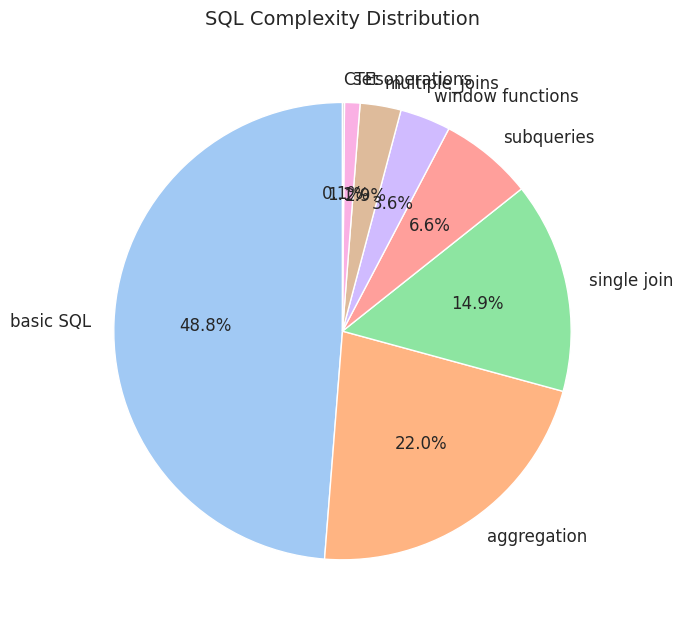

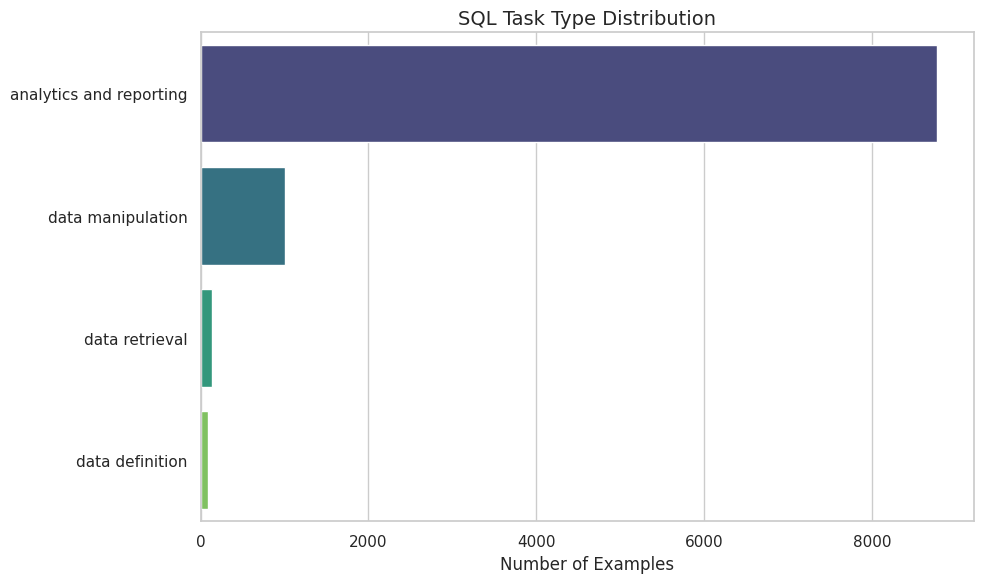

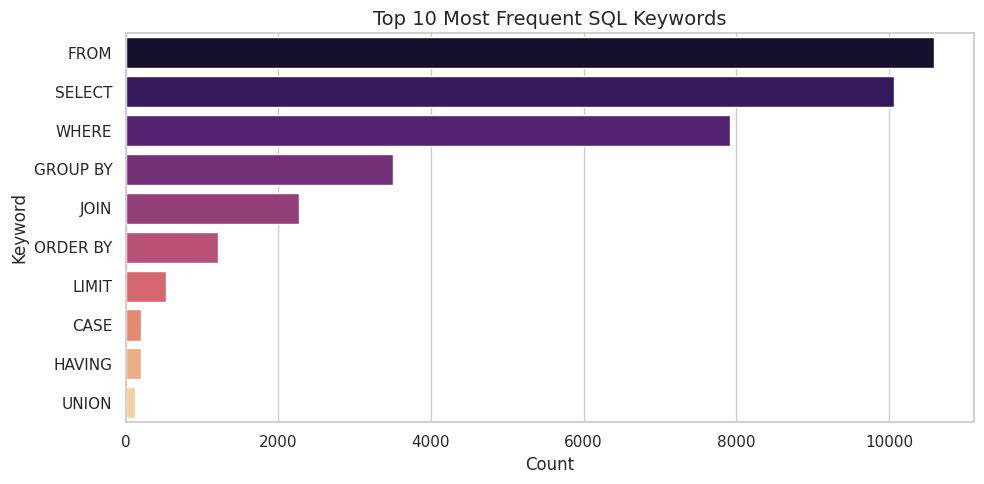

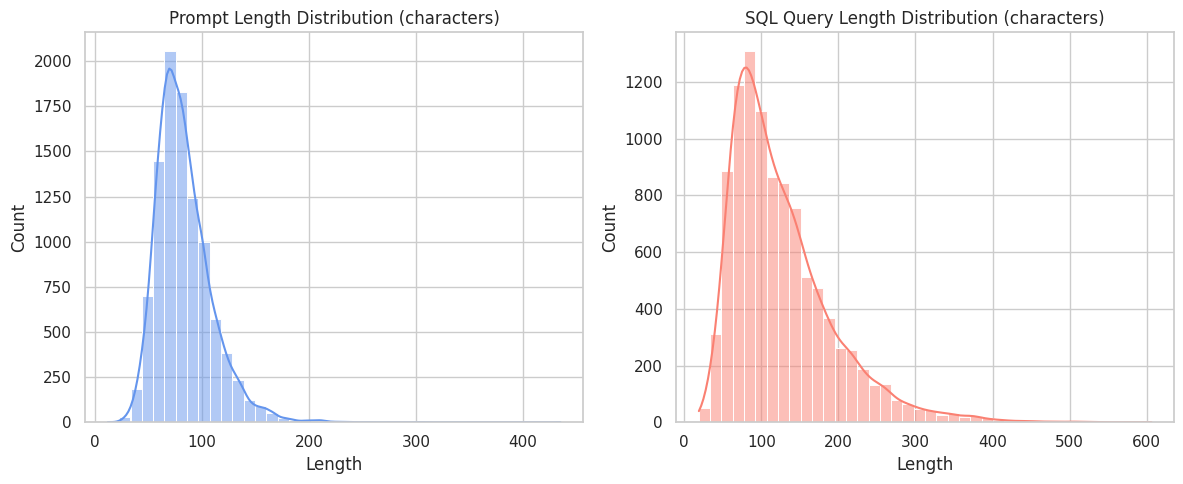

In [14]:
# =============================================================================
# STEP 0 – Environment setup & dependency installation
# =============================================================================
# Install only the packages we actually use (removed unused 'dataset')
!pip install -q sqlglot datasets

# =============================================================================
# STEP 1 – Import libraries
# =============================================================================
import json
import logging
import random
import re
from collections import Counter

import sqlglot
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset
from huggingface_hub import login

# Silence noisy dataset logging
logging.getLogger("datasets").setLevel(logging.ERROR)

# For reproducibility (very important when doing data augmentation)
RANDOM_SEED = 42
random.seed(RANDOM_SEED)

# =============================================================================
# STEP 2 – Mount Google Drive (persistent storage)
# =============================================================================
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

# =============================================================================
# STEP 3 – Authenticate to Hugging Face
# =============================================================================
from google.colab import userdata
hf_token = userdata.get('HF_TOKEN')
login(token=hf_token)

# =============================================================================
# STEP 4 – Load source dataset (10k slice)
# =============================================================================
print("Loading Gretel synthetic text-to-SQL dataset...")
ds = load_dataset("gretelai/synthetic_text_to_sql", split="train")
raw_subset = ds.shuffle(seed=RANDOM_SEED).select(range(10000))
print(f"→ Loaded {len(raw_subset)} examples")

# =============================================================================
# STEP 5 – Define transformation function (core data preparation logic)
# =============================================================================
def apply_tinycode_logic(example, idx: int):
    """
    Transform one example into a BigQuery-optimized, chat-formatted instruction.
    Applies several realistic augmentations useful for fine-tuning.
    """
    # Make transformations deterministic per example
    random.seed(RANDOM_SEED + idx)

    original_sql   = example['sql']
    schema         = example['sql_context']
    question       = example['sql_prompt']
    explanation    = example['sql_explanation']

    # ── Layer 1 & 3: Dialect conversion + BigQuery safety improvements ──
    try:
        # Transpile → BigQuery with automatic backticks on identifiers
        bq_sql = sqlglot.transpile(
            original_sql,
            read=None,               # let sqlglot guess source dialect
            write="bigquery",
            identify=True            # force quoting of identifiers
        )[0]

        # Replace dangerous CAST → SAFE_CAST (more careful version)
        bq_sql = re.sub(
            r'\bCAST\s*\(',
            'SAFE_CAST(',
            bq_sql,
            flags=re.IGNORECASE
        )
    except Exception:
        bq_sql = original_sql  # fallback – better than crashing

    # ── Layer 2: Negative example – sometimes add irrelevant table ──
    if random.random() < 0.22:
        distractors = [
            "\nCREATE TABLE `archive_users_2024` (user_id INT64, email STRING, deleted_at TIMESTAMP);",
            "\nCREATE TABLE `marketing_events` (event_id INT64, campaign_name STRING, cost FLOAT64);",
            "\nCREATE TABLE `raw_logs` (log_time TIMESTAMP, payload STRING);"
        ]
        schema += random.choice(distractors)

    # ── Layer 4: Value grounding – realistic sample values hint ──
    grounding_hint = "\n-- Note: common status values are usually 'ACTIVE', 'PENDING', 'SUSPENDED', 'CANCELLED'"
    schema += grounding_hint

    # ── Layer 5: Prompt style variation (realistic user phrasing) ──
    prompt_styles = [
        "",                             # neutral / original
        "Could you please ",
        "Hey, can you ",
        "Write a BigQuery SQL query that ",
        "Using GoogleSQL, ",
        "I need to ",
    ]
    augmented_question = random.choice(prompt_styles) + question

    # ── Final formatting: modern Gemma-3 / Llama-3 style chat template ──
    formatted = f"""<|begin_of_text|><|start_header_id|>system<|end_header_id|>
You are an expert BigQuery SQL developer. Always follow GoogleSQL best practices:
• Use backticks for identifiers
• Prefer SAFE_CAST, SAFE_DIVIDE, etc.
• Write readable, well-formatted SQL
<|eot_id|>
<|start_header_id|>user<|end_header_id|>
### SCHEMA:
{schema}

### QUESTION:
{augmented_question}
<|eot_id|><|start_header_id|>assistant<|end_header_id|>
{explanation}

```sql
{bq_sql}
```<|eot_id|>"""

    return {"text": formatted}


# =============================================================================
# STEP 6 – Apply transformation to all examples
# =============================================================================
print("Applying BigQuery-specific augmentations...")
tinycode_train_ds = raw_subset.map(
    apply_tinycode_logic,
    with_indices=True,
    desc="Transforming examples",
    remove_columns=raw_subset.column_names
)
print("→ Transformation complete")

# Quick sanity check
print("\nFirst formatted example preview:")
print(tinycode_train_ds[0]["text"][:600], "...\n")

# =============================================================================
# STEP 7 – (Optional) Save the prepared dataset
# =============================================================================
# Uncomment to push to your Hugging Face hub
# tinycode_train_ds.push_to_hub("your-username/gretel-bigquery-tuned-10k", private=True)

# Or save locally / to Drive
# tinycode_train_ds.to_json("/content/drive/MyDrive/bigquery-tuned-10k.jsonl")

# =============================================================================
# STEP 8 – Exploratory Data Analysis & Visualizations (on ORIGINAL data)
# =============================================================================
print("\nGenerating dataset statistics and plots...")

df = raw_subset.to_pandas()

sns.set_theme(style="whitegrid")

# ── 8.1 SQL Complexity distribution ──
plt.figure(figsize=(7, 7))
df['sql_complexity'].value_counts().plot.pie(
    autopct='%1.1f%%',
    colors=sns.color_palette('pastel'),
    startangle=90,
    textprops={'fontsize': 12}
)
plt.title('SQL Complexity Distribution', fontsize=14, pad=15)
plt.ylabel('')
plt.tight_layout()
plt.savefig('sql_complexity_pie.png', dpi=150, bbox_inches='tight')

# ── 8.2 Task type distribution ──
plt.figure(figsize=(10, 6))
task_order = df['sql_task_type'].value_counts().index
sns.countplot(
    data=df,
    y='sql_task_type',
    order=task_order,
    palette='viridis'
)
plt.title('SQL Task Type Distribution', fontsize=14)
plt.xlabel('Number of Examples')
plt.ylabel('')
plt.tight_layout()
plt.savefig('task_type_bar.png', dpi=150, bbox_inches='tight')

# ── 8.3 Top SQL keywords ──
def extract_keywords(sql_list):
    keywords = []
    pattern = r'\b(SELECT|FROM|JOIN|WHERE|GROUP BY|ORDER BY|LIMIT|HAVING|WITH|UNION|CASE|CAST|SAFE_CAST)\b'
    for sql in sql_list:
        found = re.findall(pattern, sql.upper())
        keywords.extend(found)
    return Counter(keywords)

kw_counts = extract_keywords(df['sql'].tolist())
kw_df = pd.DataFrame(kw_counts.most_common(10), columns=['Keyword', 'Count'])

plt.figure(figsize=(10, 5))
sns.barplot(data=kw_df, x='Count', y='Keyword', palette='magma')
plt.title('Top 10 Most Frequent SQL Keywords', fontsize=14)
plt.tight_layout()
plt.savefig('keyword_frequency.png', dpi=150, bbox_inches='tight')

# ── 8.4 Prompt & SQL length distribution ──
df['prompt_len'] = df['sql_prompt'].str.len()
df['sql_len']    = df['sql'].str.len()

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df['prompt_len'], bins=40, color='cornflowerblue', kde=True)
plt.title('Prompt Length Distribution (characters)')
plt.xlabel('Length')

plt.subplot(1, 2, 2)
sns.histplot(df['sql_len'], bins=40, color='salmon', kde=True)
plt.title('SQL Query Length Distribution (characters)')
plt.xlabel('Length')

plt.tight_layout()
plt.savefig('length_distribution.png', dpi=150, bbox_inches='tight')

print("→ All plots saved")
plt.show()

In [ ]:
#------------------------- structured original -ignore---------------------------------

In [13]:
# ==============================================================
# Step#1: Import Required Libraries
# These libraries support data processing, SQL transformation,
# visualization, and dataset manipulation.
# ==============================================================

import random
import re
import sqlglot
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter


# ==============================================================
# Step#2: Define Preprocessing Function
# This function applies TinyCode preprocessing logic to each
# dataset record and prepares a structured training prompt.
# ==============================================================

def apply_tinycode_logic(example):

    # ----------------------------------------------------------
    # Step#2.1: Extract Required Fields from Dataset Record
    # ----------------------------------------------------------
    original_sql = example['sql']                 # Original SQL query
    schema = example['sql_context']               # Database schema
    question = example['sql_prompt']              # Natural language question
    explanation = example['sql_explanation']      # Explanation of query


    # ----------------------------------------------------------
    # Step#2.2: SQL Dialect Transpilation & BigQuery Normalization
    # Convert SQL to BigQuery dialect using sqlglot and enforce
    # best practices like SAFE_CAST.
    # ----------------------------------------------------------
    try:
        # Convert SQL to BigQuery dialect
        bq_sql = sqlglot.transpile(
            original_sql,
            read=None,
            write="bigquery",
            identify=True
        )[0]

        # Replace CAST with SAFE_CAST to prevent errors
        bq_sql = bq_sql.replace("CAST(", "SAFE_CAST(")
        bq_sql = bq_sql.replace("cast(", "safe_cast(")

    except:
        # If SQL transpilation fails, use original SQL
        bq_sql = original_sql


    # ----------------------------------------------------------
    # Step#2.3: Schema Augmentation (Negative Sampling)
    # Add irrelevant tables randomly to simulate real-world
    # noisy database schemas.
    # ----------------------------------------------------------
    if random.random() < 0.20:

        distractor_table = """
CREATE TABLE `irrelevant_metadata` (
    id INT64,
    log_date DATE,
    notes STRING
);
"""

        schema = schema + distractor_table


    # ----------------------------------------------------------
    # Step#2.4: Sample Row Injection (Value Grounding)
    # Add hints about possible column values to guide the model.
    # ----------------------------------------------------------
    grounding_hint = """
-- Sample Rows: If filtering by status, values are usually
-- ['ACTIVE', 'PENDING', 'CLOSED'].
"""

    schema = schema + grounding_hint


    # ----------------------------------------------------------
    # Step#2.5: Multi-style Prompt Augmentation
    # Randomly modify the question style to simulate
    # different user query patterns.
    # ----------------------------------------------------------
    styles = [
        "",
        "Hey, can you ",
        "Write a BigQuery script to ",
        "Using GoogleSQL, ",
        "Query the database for: "
    ]

    augmented_question = random.choice(styles) + question


    # ----------------------------------------------------------
    # Step#2.6: Format Final Prompt Using Chat Template
    # Structure the training example using system/user/assistant
    # tokens for LLM training.
    # ----------------------------------------------------------
    formatted_text = f"""<|begin_of_text|><|start_header_id|>system<|end_header_id|>
You are an expert BigQuery Developer. Follow GoogleSQL best practices including backticks and SAFE functions.
<|eot_id|>
<|start_header_id|>user<|end_header_id|>

### CONTEXTUAL SCHEMA:
{schema}

### USER REQUEST:
{augmented_question}

<|eot_id|><|start_header_id|>assistant<|end_header_id|>

{explanation}

```sql
{bq_sql}
```<|eot_id|>"""

    return formatted_text

In [ ]:
#-------------------------- output original 100 -------------------------------------

In [1]:
!pip install -q sqlglot dataset

#Import Relevant Library

import json
import logging
import sqlglot
import random

from datasets import load_dataset
from huggingface_hub import login

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import re
from collections import Counter



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 34.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython-sql 0.5.0 requires sqlalchemy>=2.0, but you have sqlalchemy 1.4.54 which is incompatible.
google-adk 1.26.0 requires sqlalchemy<3.0.0,>=2.0, but you have sqlalchemy 1.4.54 which is incompatible.


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
#TODO: Not using the currently, will remove this later.
import shutil
import os
src_file = f'/content/my_bigquery_subset.jsonl'
dst_file = f'/content/drive/MyDrive/AAI-590-IN1/my_bigquery_subset.jsonl'

if os.path.exists(src_file) and not os.path.exists(dst_file):
  shutil.copy(src_file, dst_file)
else:
  print("Datafile is already present.")

#-----------------------------

Datafile is already present.


In [5]:
#TODO: Not using the currently, will remove this later.
import shutil
import os
src_file = f'/content/my_bigquery_subset.jsonl'
dst_file = f'/content/drive/MyDrive/AAI-590-IN1/my_bigquery_subset.jsonl'

if os.path.exists(src_file) and not os.path.exists(dst_file):
  shutil.copy(src_file, dst_file)
else:
  print("Datafile is already present.")

#-----------------------------

Datafile is already present.


In [9]:
#--------------Load Dataset

# 1. Load Gretel Dataset (10k slice) for building the framework.
#
ds = load_dataset("gretelai/synthetic_text_to_sql", split="train")
raw_subset = ds.select(range(100))


<|begin_of_text|><|start_header_id|>system<|end_header_id|>
You are an expert BigQuery Developer. Follow GoogleSQL best practices including backticks and SAFE functions.<|eot_id|>
<|start_header_id|>user<|end_header_id|>
### CONTEXTUAL SCHEMA:
CREATE TABLE salesperson (salesperson_id INT, name TEXT, region TEXT); INSERT INTO salesperson (salesperson_id, name, region) VALUES (1, 'John Doe', 'North'), (2, 'Jane Smith', 'South'); CREATE TABLE timber_sales (sales_id INT, salesperson_id INT, volume REAL, sale_date DATE); INSERT INTO timber_sales (sales_id, salesperson_id, volume, sale_date) VALUES (1, 1, 120, '2021-01-01'), (2, 1, 150, '2021-02-01'), (3, 2, 180, '2021-01-01');
-- Sample Rows: If filtering by status, values are usually ['ACTIVE', 'PENDING', 'CLOSED'].

### USER REQUEST:
Hey, can you What is the total volume of timber sold by each salesperson, sorted by salesperson?
<|eot_id|><|start_header_id|>assistant<|end_header_id|>

Joins timber_sales and salesperson tables, groups sale

/tmp/ipykernel_287/951144031.py:92: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='sql_task_type', order=task_order, palette='viridis')
/tmp/ipykernel_287/951144031.py:112: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=kw_df.head(10), x='Frequency', y='Keyword', palette='magma')


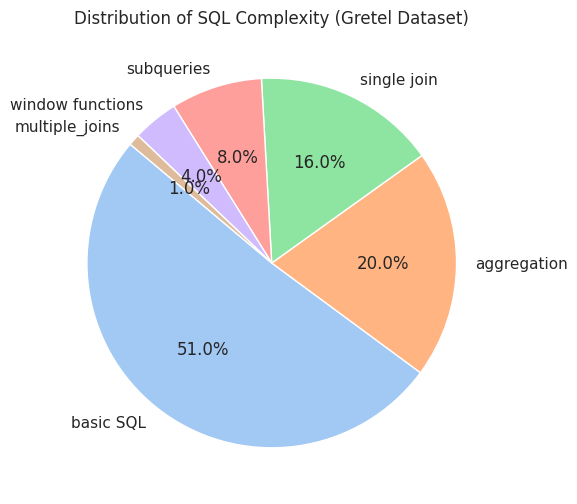

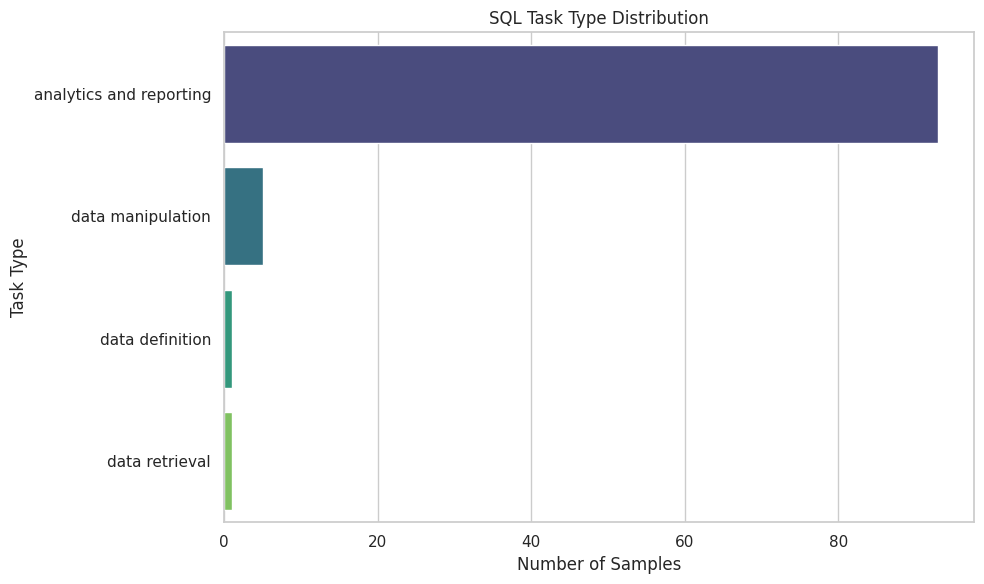

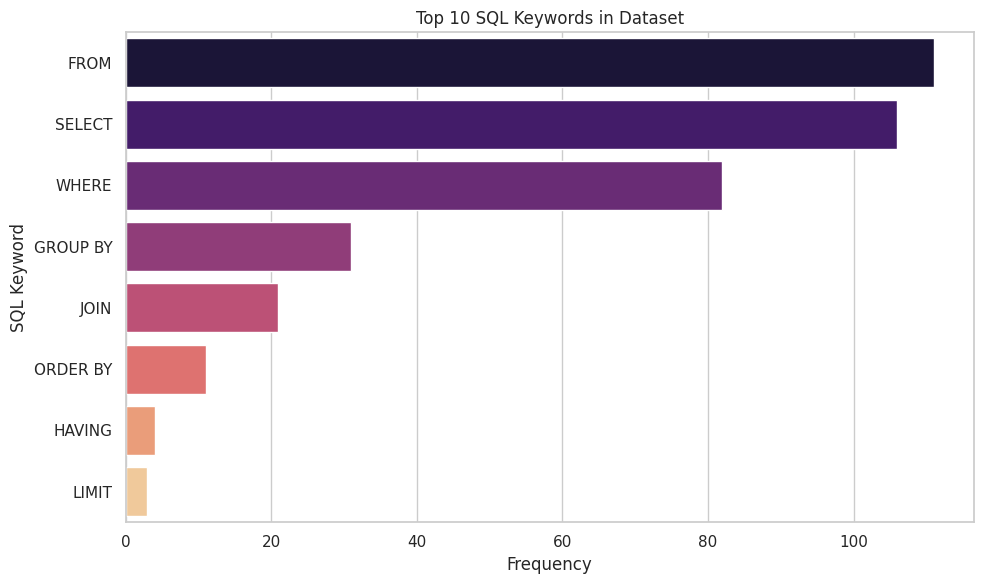

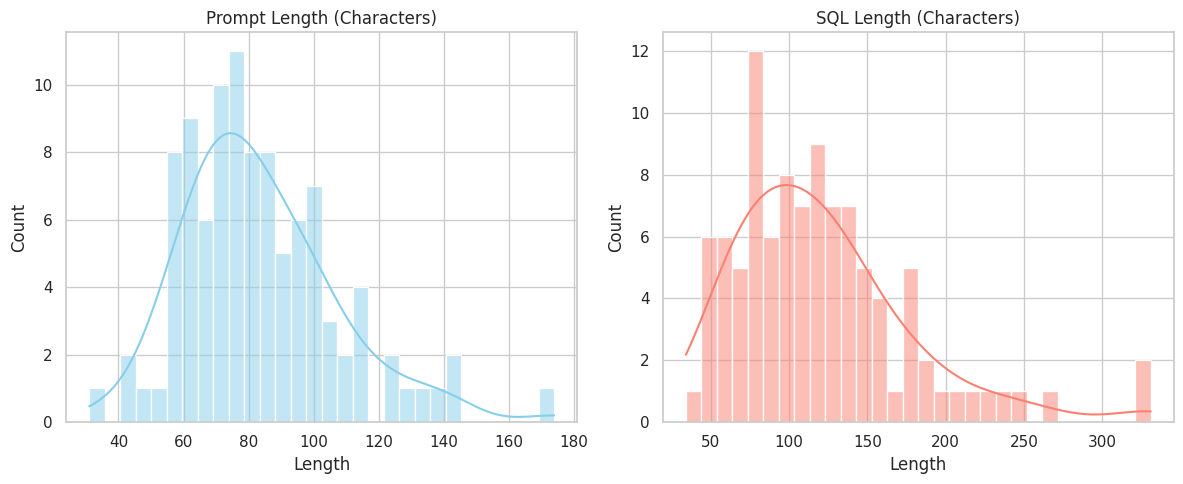

In [10]:
#-------------Preprocessing & Visualisations

def apply_tinycode_logic(example):
    original_sql = example['sql']
    schema = example['sql_context']
    question = example['sql_prompt']
    explanation = example['sql_explanation']

    # --- LAYER 1 & 3: Dialect Transpilation & BQ Normalization ---
    try:
        # Transpile to BigQuery and force backticks (identify=True)
        bq_sql = sqlglot.transpile(original_sql, read=None, write="bigquery", identify=True)[0]

        # BQ Normalization: SAFE_CAST and QUALIFY
        # (Example: replace risky CASTs with SAFE_CAST)
        bq_sql = bq_sql.replace("CAST(", "SAFE_CAST(").replace("cast(", "safe_cast(")
    except:
        bq_sql = original_sql

    # --- LAYER 2: Schema Pruning (Negative Sampling) ---
    # In 20% of cases, we add a "distractor" table to the schema
    if random.random() < 0.20:
        distractor = "\nCREATE TABLE `irrelevant_metadata` (id INT64, log_date DATE, notes STRING);"
        schema = schema + distractor

    # --- LAYER 4: Sample Row Injection (Value Grounding) ---
    # We simulate sample rows to help the model understand data values
    # In a real project, you'd pull these from the DB. Here we inject a hint.
    grounding_hint = "\n-- Sample Rows: If filtering by status, values are usually ['ACTIVE', 'PENDING', 'CLOSED']."
    schema = schema + grounding_hint

    # --- LAYER 5: Multi-style Augmentation ---
    # Randomly prefix questions to simulate different user styles
    styles = [
        "", # Standard
        "Hey, can you ",
        "Write a BigQuery script to ",
        "Using GoogleSQL, ",
        "Query the database for: "
    ]
    augmented_question = random.choice(styles) + question

    # --- FINAL FORMATTING: Gemma 3 Chat Template ---
    formatted_text = f"""<|begin_of_text|><|start_header_id|>system<|end_header_id|>
You are an expert BigQuery Developer. Follow GoogleSQL best practices including backticks and SAFE functions.<|eot_id|>
<|start_header_id|>user<|end_header_id|>
### CONTEXTUAL SCHEMA:
{schema}

### USER REQUEST:
{augmented_question}
<|eot_id|><|start_header_id|>assistant<|end_header_id|>

{explanation}

```sql
{bq_sql}
```<|eot_id|>"""

    return {"text": formatted_text}

# Apply all logic
tinycode_train_ds = raw_subset.map(apply_tinycode_logic, remove_columns=raw_subset.column_names)

# Verify the first record
print(tinycode_train_ds[0]['text'])


#------------------------------------------
# Assuming 'train_data' is your dataset object from:
# train_data = load_dataset("gretelai/synthetic_text_to_sql", split="train").select(range(10000))
# Create DataFrame from raw_subset to retain original columns for analysis
df = raw_subset.to_pandas()

# Set the visualization style
sns.set_theme(style="whitegrid")

# 1. SQL Complexity Distribution
plt.figure(figsize=(8, 6))
df['sql_complexity'].value_counts().plot.pie(
    autopct='%1.1f%%',
    colors=sns.color_palette('pastel'),
    startangle=140
)
plt.title('Distribution of SQL Complexity (Gretel Dataset)')
plt.ylabel('')
plt.savefig('sql_complexity_pie.png')

# 2. SQL Task Type Distribution
plt.figure(figsize=(10, 6))
task_order = df['sql_task_type'].value_counts().index
sns.countplot(data=df, y='sql_task_type', order=task_order, palette='viridis')
plt.title('SQL Task Type Distribution')
plt.xlabel('Number of Samples')
plt.ylabel('Task Type')
plt.tight_layout()
plt.savefig('task_type_bar.png')

# 3. SQL Keyword Frequency (Top 10)
def get_keywords(sql_list):
    keywords = []
    for sql in sql_list:
        # Regex to find major SQL keywords
        found = re.findall(r'\b(SELECT|FROM|JOIN|WHERE|GROUP BY|ORDER BY|LIMIT|CASE|CAST|UNION|WITH|HAVING)\b', sql.upper())
        keywords.extend(found)
    return Counter(keywords)

kw_counts = get_keywords(df['sql'].tolist())
kw_df = pd.DataFrame(kw_counts.items(), columns=['Keyword', 'Frequency']).sort_values(by='Frequency', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=kw_df.head(10), x='Frequency', y='Keyword', palette='magma')
plt.title('Top 10 SQL Keywords in Dataset')
plt.xlabel('Frequency')
plt.ylabel('SQL Keyword')
plt.tight_layout()
plt.savefig('keyword_frequency.png')

# 4. Prompt vs SQL Length Distribution
df['prompt_len'] = df['sql_prompt'].apply(len)
df['sql_len'] = df['sql'].apply(len)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df['prompt_len'], bins=30, color='skyblue', kde=True)
plt.title('Prompt Length (Characters)')
plt.xlabel('Length')

plt.subplot(1, 2, 2)
sns.histplot(df['sql_len'], bins=30, color='salmon', kde=True)
plt.title('SQL Length (Characters)')
plt.xlabel('Length')

plt.tight_layout()
plt.savefig('length_distribution.png')

# Show all plots
plt.show()

In [ ]:
#---------------------------------------  end of code -----------------------------------